# 📓 **Notebook 1 — Phases 1 & 2**

**Project:** [Medical Transcription Classfier and Semantic Search Engine Project](https://github.com/bahadirkoko/medical-transcription-classifier)

## **Medical Transcription Analysis — Phases 1 & 2**

This notebook covers exploratory analysis and statistical feature analysis of the
Medical Transcriptions dataset, preparing the groundwork for classification (Phase 3)
and semantic search (Phase 4).

## **Phase 1 — EDA & NLP Foundations**
Clean the data and understand the linguistic "fingerprint" of each medical specialty.
- **1.1 Cleaning & Features** — remove nulls/duplicates/short notes; compute length,
  word, and sentence counts; visualize class distribution and note lengths.
- **1.2 NLP Analysis** — preprocess text (lowercase, remove punctuation, drop stopwords);
  find top words, bigrams, and trigrams per specialty.

## **Phase 2 — Statistical Significance & Linguistic Importance**
Statistically measure which words and phrases are tied to each specialty.
- **2.1 Chi-Square** — tests which words are statistically "locked" to a specialty.
- **2.2 N-Grams + PMI** — finds meaningful medical phrases vs. random word pairings.
- **2.3 TF-IDF** — scores words by uniqueness, filtering out common "medical noise."


---

### 🗂️ **Project notebooks**
1. **Notebook 1** — Phases 1 & 2: Collection & Cleaning, Preprocessing for NLP, TF-IDF, Chi 2 **(you are here)**
2. Notebook 2 — Phase 3: Model Trainings and Evaluation 
3. Notebook 3 — Phases 4 & 5: Semantic Search Engine, Retrieval Validation

In [1]:
#data libraries
import pandas as pd
import numpy as np

#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#text/NLP libraries
import re #punctuation removal
import nltk #cleaning, tokenization, stopword removal, n-grams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from collections import Counter #n-gram frequency counting

#ML work phase 1.2, vectorization and phase 2
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2

#NLTK data downloads
nltk.download('punkt') #downloads the Punkt tokenizer models, which are used for sentence splitting and tokenization.
nltk.download('punkt_tab') #downloads the Punkt tokenizer models for tokenizing text into sentences and words, specifically for tab-separated text.
nltk.download('stopwords') #downloads the stopwords corpus, which contains a list of common stopwords in various languages that can be used for text preprocessing and filtering.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Phase 1.1 EDA

Before any cleaning, we load the raw dataset and inspect its structure —
dimensions, column quality (nulls and duplicates), and transcription length
distribution. This informs every cleaning decision that follows: we only
drop what we can justify from what we observe here.


In [2]:
df = pd.read_csv('../data/raw/medicaltranscriptionsamples.csv') #loading data from a relative path

print("Rows:", df.shape[0], "Columns:", df.shape[1]) #to get the number of rows and columns in the DataFrame
display(df.head())

df = df.drop(columns=['Unnamed: 0']) #dropping the unnamed column 

null_and_duplicated = pd.DataFrame({
    'null_%': (df.isnull().sum() / len(df) * 100).round(2), #getting the percentage of null values in each column, rounded to 2 decimal places, no need for lambda because .isnull works on the entire DataFrame and returns a Series with the count of null values for each column.
    'duplicated_%': (df.apply(lambda c: c.duplicated().sum()) / len(df) * 100).round(2) # duplicated() is series method, so we need to apply it to each column using apply() and then sum the boolean values to get the count of duplicated values for each column. Then we divide by the total number of rows and multiply by 100 to get the percentage of duplicated values in each column, rounded to 2 decimal places.
})
display(null_and_duplicated)

print(f"Missing values in 'medical_specialty': {df['medical_specialty'].isna().sum()}") #checking for missing values 
print(f"Missing values in 'transcription': {df['transcription'].isna().sum()}")

thresholds = [20, 50, 100, 200, 500] #transcription char length checking

threshold_summary = pd.DataFrame({
    'threshold': thresholds,
    'count': [( df['transcription'].str.len() < t).sum() for t in thresholds]}) #loop each threshhold and count len of transcriptions

display(threshold_summary)



Rows: 4999 Columns: 6


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


,null_%,duplicated_%
description,0.00,53.03
medical_specialty,0.00,99.20
sample_name,0.00,52.45
transcription,0.66,52.83
keywords,21.36,22.98


Missing values in 'medical_specialty': 0
Missing values in 'transcription': 33


,threshold,count
0,20,14
1,50,23
2,100,45
3,200,64
4,500,132


**Key Findings:**

- **medical_specialty:** 0 nulls, ~99% duplicated — expected for a categorical
  column with only ~30 distinct values. Not a concern.

- **transcription:** 33 nulls (to be dropped) and ~52% duplicated values.
  The high duplication rate suggests the same clinical note is cross-listed
  under multiple specialties — a structural property of this dataset worth
  investigating before modeling, as it affects train/test integrity.

- **Short notes:** a meaningful number of transcriptions have very few
  characters. Notes under a minimum threshold likely lack enough content
  to carry specialty signal and will be considered for removal after
  further inspection.

In [3]:
# specialty counts to inform our dropping decisions
specialty_summary = (
    df.groupby('medical_specialty')['transcription'] #groupby specialties to see how much notes we have
    .count()
    .reset_index() #reset index
    .rename(columns={'transcription': 'note_count'})
    .sort_values('note_count', ascending=False)
    .assign(percentage=lambda x: (x['note_count'] / len(df) * 100).round(2)) #adding another column and applying percentage formula to each specialty, used assign not to break mid way df creation
    .reset_index(drop=True) #reset index again to finalize
)
display(specialty_summary)

print(f"total specialties: {specialty_summary['medical_specialty'].nunique()}") #count number of unique labels
print(f"specialties with < 20 notes: {(specialty_summary['note_count'] < 20).sum()}")
print(f"specialties with < 10 notes: {(specialty_summary['note_count'] < 10).sum()}")




,medical_specialty,note_count,percentage
0,Surgery,1088,21.76
1,Consult - History and Phy.,516,10.32
2,Cardiovascular / Pulmonary,371,7.42
3,Orthopedic,355,7.10
4,Radiology,273,5.46
5,General Medicine,259,5.18
6,Gastroenterology,224,4.48
7,Neurology,223,4.46
8,SOAP / Chart / Progress Notes,166,3.32
9,Urology,156,3.12


total specialties: 40
specialties with < 20 notes: 11
specialties with < 10 notes: 5


**Key findings:**

The dataset contains **40 labeled specialties**, but not all are genuine
clinical fields. Some labels describe **document formats** (SOAP Notes,
Letters, Discharge Summaries, etc.) rather than medical specialties —
these likely represent the same transcriptions re-labeled for administrative
purposes.

**Two issues to address before modeling:**

1. **Document-format labels** — non-specialty categories that overlap with
   real specialties on the same transcription text. If confirmed redundant,
   dropping them removes no unique clinical content and makes the
   classification task coherent (we classify *medical fields*, not
   *note formats*).

2. **Rare specialties** — X specialties have fewer than 10 notes and
   Y have fewer than 20. With so few examples, a model cannot learn
   reliable patterns, and stratified train/test splitting becomes
   unstable. Dropping these improves classifier reliability on the
   remaining classes.

**Next step:** verify that non-specialty transcriptions also exist under
real specialty labels before dropping — confirming no unique content
is lost.

In [4]:
not_specialties = [
    'SOAP / Chart / Progress Notes', 'Office Notes', 'Letters',
    'Discharge Summary', 'Emergency Room Reports',
    'Consult - History and Phy.', 'IME-QME-Work Comp etc.'
]

# ── Check 1: non-specialty overlap ───────────────────────────────────────────
non_spec_transcriptions = set(
    df[df['medical_specialty'].str.strip().isin(not_specialties)]['transcription']
)
real_spec_transcriptions = set(
    df[~df['medical_specialty'].str.strip().isin(not_specialties)]['transcription']
)

also_in_real     = non_spec_transcriptions & real_spec_transcriptions
only_in_non_spec = non_spec_transcriptions - real_spec_transcriptions

overlap_rate = (len(also_in_real) / len(non_spec_transcriptions) * 100) if len(non_spec_transcriptions) > 0 else 0
print(f"=== Non-Specialty Overlap ===")
print(f"total unique transcriptions in non-specialty rows: {len(non_spec_transcriptions)}")
print(f"also labeled under a real specialty:               {len(also_in_real)}")
print(f"only in non-specialty (would be lost):             {len(only_in_non_spec)}")
print(f"overlap rate: {overlap_rate:.1f}%")

# ── Check 2: Surgery overlap ──────────────────────────────────────────────────
surgery_transcriptions = set(
    df[df['medical_specialty'].str.strip() == 'Surgery']['transcription'].str.strip()
)
other_transcriptions = set(
    df[df['medical_specialty'].str.strip() != 'Surgery']['transcription'].str.strip()
)

also_in_other = surgery_transcriptions & other_transcriptions
only_surgery  = surgery_transcriptions - other_transcriptions

print(f"\n=== Surgery Overlap ===")
print(f"total unique Surgery transcriptions: {len(surgery_transcriptions)}")
print(f"also appear under another specialty: {len(also_in_other)}")
print(f"unique to Surgery only:              {len(only_surgery)}")
print(f"overlap rate: {len(also_in_other)/len(surgery_transcriptions)*100:.1f}%")

# ── Check 3: Radiology overlap ────────────────────────────────────────────────
radiology_texts     = set(df[df['medical_specialty'].str.strip() == 'Radiology']['transcription'].str.strip())
non_radiology_texts = set(df[df['medical_specialty'].str.strip() != 'Radiology']['transcription'].str.strip())

also_elsewhere = radiology_texts & non_radiology_texts
radiology_only = radiology_texts - non_radiology_texts

print(f"\n=== Radiology Overlap ===")
print(f"total unique Radiology notes:           {len(radiology_texts)}")
print(f"also appear under another specialty:    {len(also_elsewhere)}")
print(f"unique to Radiology only:               {len(radiology_only)}")
print(f"cross-listed rate: {len(also_elsewhere)/len(radiology_texts)*100:.1f}%")

# what real specialties do the cross-listed Radiology notes belong to?
conversion_map = {}
for text in also_elsewhere:
    other = df[
        (df['transcription'].str.strip() == text) &
        (df['medical_specialty'] != 'Radiology')
    ]['medical_specialty'].tolist()
    if other:
        conversion_map[text] = other[0]

print("\ncross-listed Radiology notes belong to:")
print(pd.Series(list(conversion_map.values())).value_counts())

=== Non-Specialty Overlap ===
total unique transcriptions in non-specialty rows: 863
also labeled under a real specialty:               829
only in non-specialty (would be lost):             34
overlap rate: 96.1%

=== Surgery Overlap ===
total unique Surgery transcriptions: 1089
also appear under another specialty: 1040
unique to Surgery only:              49
overlap rate: 95.5%

=== Radiology Overlap ===
total unique Radiology notes:           273
also appear under another specialty:    262
unique to Radiology only:               11
cross-listed rate: 96.0%

cross-listed Radiology notes belong to:
Radiology                     237
Surgery                        14
Cardiovascular / Pulmonary      5
Urology                         5
Neurology                       1
Name: count, dtype: int64


**Key Findings:** 
- **96% overlap confirmed:** transcriptions labeled under non-specialty
  categories also appear under real specialty labels. Dropping the
  non-specialty rows removes only the redundant label — no unique
  clinical content is lost.

- **Note on the 4% remainder:** since we used sets (which count each
  unique transcription once), the non-overlapping transcriptions are
  genuinely unique to non-specialty labels with no real-specialty
  counterpart. These carry no usable specialty label for classification
  and would be dropped regardless.

- **Surgery Speciality overlaps** we also found out that surgery overlaps with real specialities
so we have same duplicate transcription, labeled as surgery but actually they have true label that represent a real specialty.

- Radiology speciality is cross-listed data it overlaps 95%, so dropping it will increase our accuracy 


## Phase 1.1 Data Cleaning

In [5]:
not_specialties = [ #creating a list of not specilities, that is in the data set and labeled as speciality
    'SOAP / Chart / Progress Notes', 'Office Notes', 'Letters',
    'Discharge Summary', 'Emergency Room Reports',
    'Consult - History and Phy.', 'IME-QME-Work Comp etc.','Surgery','Radiology'
]

print(df.shape[0],'Rows')
df = df.dropna(subset=['medical_specialty','transcription']) #to drop rows with missing values in the 'medical_specialty' column and transcription column
print(df.shape[0],'Rows')

df['medical_specialty'] = df['medical_specialty'].str.strip() #to remove leading and trailing whitespace from the 'medical_specialty' column
df['transcription'] = df['transcription'].str.strip() #to remove leading and trailing whitespace from the 'transcription' column

df = df.drop_duplicates(subset=['transcription', 'medical_specialty']) #to drop duplicate rows based on the 'transcription' column, if they had exact same notes
print(df.shape[0],'Rows')

df = df[df['transcription'].str.len() >= 100] #to filter the DataFrame to only include rows where the length of the 'transcription' column is at least 100 characters
print(df.shape[0],'Rows') #to check the shape of the DataFrame after filtering out short transcriptions

df = df[~df['medical_specialty'].isin(not_specialties)].reset_index(drop=True)  #filter out not specialities
print(df.shape[0],'Rows')

min_notes = 10 # setup threshold
counts = df['medical_specialty'].value_counts() #count noter per specialty
rare = counts[counts < min_notes].index.tolist() #applies threshold in boolean filter, filter on series count , index grabs specialty names from filtered series, convert from pandas index object to plain python list

print("rare specialties being dropped:", rare)

df = df[~df['medical_specialty'].isin(rare)].reset_index(drop=True) #drop rare specialties, reset the index column after dropping, isin retursn true first and we use ~
print("after dropping rare specialties:", len(df), "rows |", df['medical_specialty'].nunique(), "specialties") 
print(df.shape[0],'Rows')

specialty_summary = (
    df.groupby('medical_specialty')['transcription'] #groupby specialties to see how much notes we have
    .count()
    .reset_index() #reset index
    .rename(columns={'transcription': 'note_count'})
    .sort_values('note_count', ascending=False)
    .assign(percentage=lambda x: (x['note_count'] / len(df) * 100).round(2)) #adding another column and applying percentage formula to each specialty, used assign not to break mid way df creation
    .reset_index(drop=True) #reset index again to finalize
)
display(specialty_summary)

4999 Rows
4966 Rows
4964 Rows
4920 Rows
2623 Rows
rare specialties being dropped: ['Speech - Language', 'Lab Medicine - Pathology', 'Allergy / Immunology', 'Autopsy', 'Hospice - Palliative Care']
after dropping rare specialties: 2586 rows | 26 specialties
2586 Rows


,medical_specialty,note_count,percentage
0,Cardiovascular / Pulmonary,368,14.23
1,Orthopedic,346,13.38
2,General Medicine,257,9.94
3,Neurology,223,8.62
4,Gastroenterology,220,8.51
5,Obstetrics / Gynecology,155,5.99
6,Urology,154,5.96
7,ENT - Otolaryngology,96,3.71
8,Neurosurgery,94,3.63
9,Hematology - Oncology,90,3.48


**Key Outcomes:**
- Null values in transcription, and specialty column dropped.
- Leading and trailing whitespaces are removed, duplicates values dropped in both transcription and medical specialty.
- Notes that have less than 100 char are dropped.
- Specialities that has less than 10 notes are dropped.
- Non-speciality values are dropped.
- After dropping non-specialties, rare classes (<10 notes), and Surgery
(96% overlap with other specialties — largely cross-listed procedural
notes): + cross listed radiology.
- 26 genuine clinical specialties | ~2586 notes
- Imbalance ratio: 36:1 (Cardiovascular 368 notes vs
  Rheumatology/Diets 10 notes each)

## Phase 1.1 Feature Extraction

In [6]:
df['char_length'] = df['transcription'].str.len() #to create a new column 'char_length' that contains the length of the text in the 'transcription' column
df['word_count'] = df['transcription'].str.split().apply(len) #to create a new column 'word_count' that contains the number, splitting by whitespace
df['sentence_count'] = df['transcription'].apply(lambda note: len(sent_tokenize(note))) #NLTK handles edge cases and abbreviations, lambda function run with apply, calculate sentence c
df[['char_length', 'word_count', 'sentence_count']].describe()




,char_length,word_count,sentence_count
count,2586.000000,2586.000000,2586.000000
mean,3076.738979,469.167827,29.700309
std,1968.206492,312.341082,19.908308
min,100.000000,9.000000,1.000000
25%,1629.000000,243.000000,15.000000
50%,2694.000000,401.000000,25.000000
75%,4048.000000,621.750000,40.000000
max,18425.000000,3029.000000,159.000000


## 1.1  Visuals

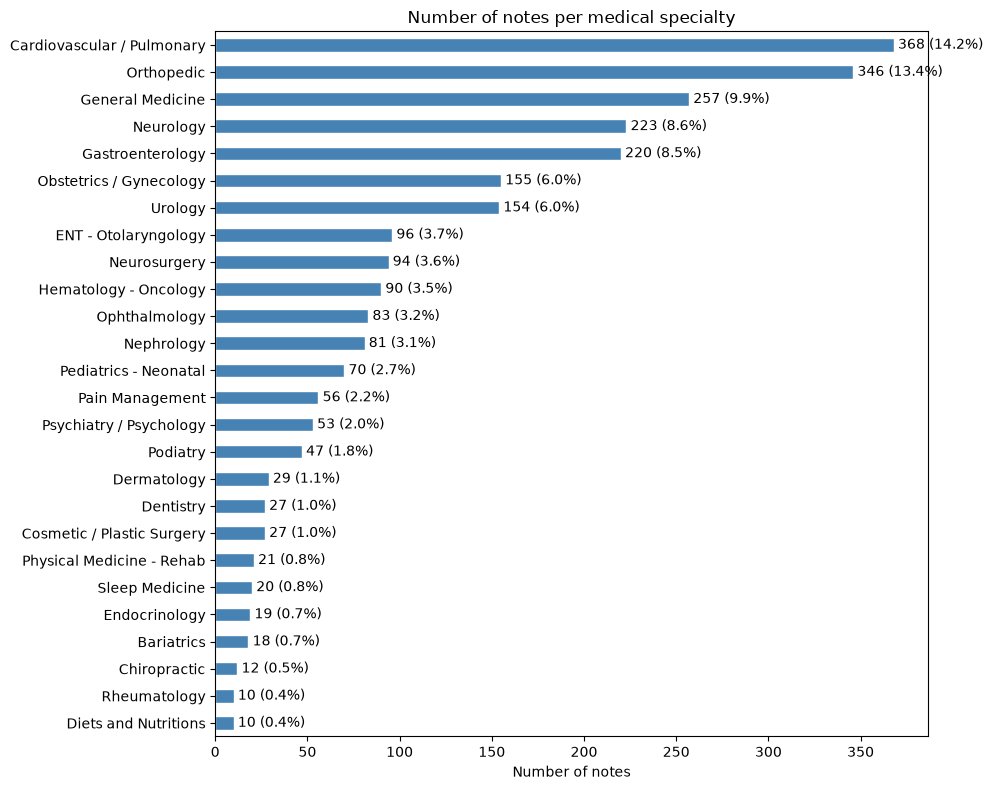

In [7]:
# create figure and axes with specified size
fig, ax = plt.subplots(figsize=(10, 8))

# count notes per specialty, sorted ascending so largest bar is at the top
specialty_counts = df['medical_specialty'].value_counts().sort_values()

# plot as horizontal bar chart — horizontal because specialty names are long
bars = specialty_counts.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)

# build labels showing count and percentage of total dataset
total = len(df)
labels = [f"{v} ({v/total*100:.1f}%)" for v in specialty_counts.values]

# place labels at the end of each bar with a small gap (padding=3)
ax.bar_label(ax.containers[0], labels=labels, padding=3)

plt.title('Number of notes per medical specialty')
plt.xlabel('Number of notes')
plt.ylabel('')          # no y-axis label needed — specialty names are self-explanatory
plt.tight_layout()      # prevent specialty names being clipped at the edges

# save before show — after show() the figure is cleared and save would produce blank
plt.savefig('../outputs/figures/specialty_counts.png', dpi=150, bbox_inches='tight')
plt.show()

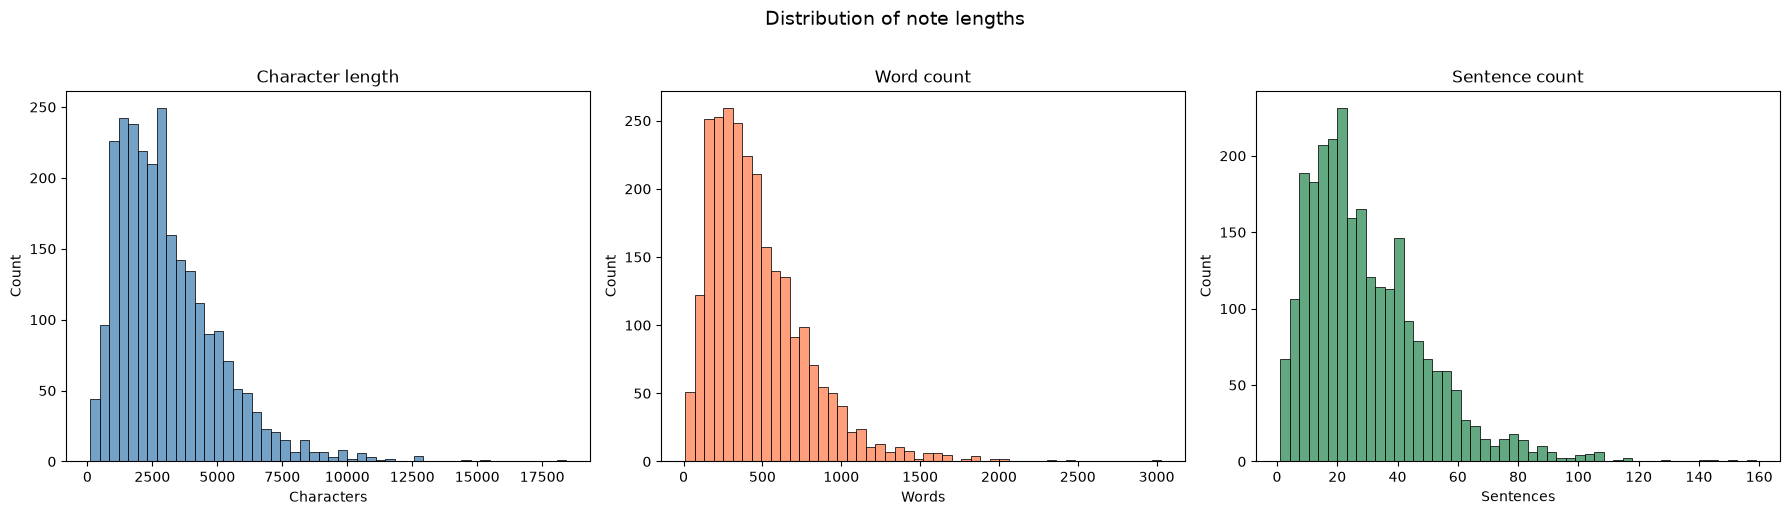

In [8]:
# one figure with three side-by-side panels — 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# panel 1 — character length distribution
sns.histplot(df['char_length'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Character length')
axes[0].set_xlabel('Characters')

# panel 2 — word count distribution
sns.histplot(df['word_count'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Word count')
axes[1].set_xlabel('Words')

# panel 3 — sentence count distribution
sns.histplot(df['sentence_count'], bins=50, ax=axes[2], color='seagreen')
axes[2].set_title('Sentence count')
axes[2].set_xlabel('Sentences')

# suptitle spans all three panels; y=1.02 lifts it above the individual titles
fig.suptitle('Distribution of note lengths', fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig('../outputs/figures/length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

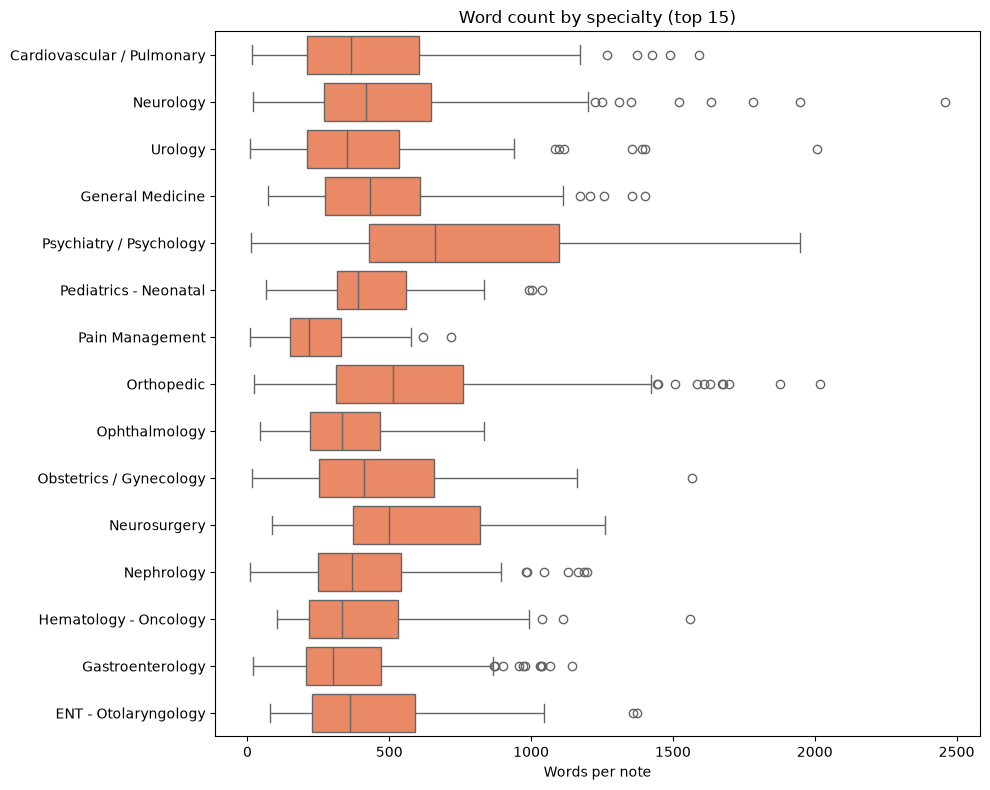

In [9]:
# limit to top 15 specialties by note count — 27 specialties is too many to read on one plot
top_specs = df['medical_specialty'].value_counts().head(15).index
subset = df[df['medical_specialty'].isin(top_specs)]

plt.figure(figsize=(10, 8))

# horizontal boxplot — specialty on y-axis so long names don't overlap
# each box shows: median (line), middle 50% (box), full range (whiskers), outliers (dots)
sns.boxplot(data=subset, y='medical_specialty', x='word_count', color='coral')

plt.title('Word count by specialty (top 15)')
plt.xlabel('Words per note')
plt.ylabel('')       # specialty names are self-explanatory, no axis label needed
plt.tight_layout()
plt.savefig('../outputs/figures/wordcount_by_specialty.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 1.2 — NLP Text Preprocessing

Before any statistical analysis, we clean the transcription text into a
normalized form suitable for word-level analysis and vectorization. The cleaning
pipeline lowercases, strips punctuation/digits, removes common English stopwords,
and rejoins — producing a `clean_text` column used by all Phase 2 methods.

**Note:** this cleaned text is used for the *classifier and statistical analysis*
(TF-IDF, chi-square). The *raw* transcription is kept for the Phase 4 semantic
search, since embedding models prefer natural language with stopwords intact.

In [10]:
# build the cleaning function and apply it to every note
stop = set(stopwords.words('english'))   # set for fast O(1) membership lookup

def clean(text):
    text = text.lower()                          # 1. lowercase — "Heart" and "heart" become one word
    text = re.sub(r'[^a-z\s]', ' ', text)        # 2. replace anything not a-z or whitespace with a SPACE
                                                 #    (space, not '' — prevents word fusion across punctuation)
    words = text.split()                         # 3. tokenize on whitespace
    words = [w for w in words if w not in stop]  # 4. drop stopwords (the, and, of...) via list comprehension
    return ' '.join(words)                       # 5. rejoin into a clean string

# apply to every transcription -> new clean_text column
df['clean_text'] = df['transcription'].apply(clean)
df.head(1)

,description,medical_specialty,sample_name,transcription,keywords,char_length,word_count,sentence_count,clean_text
0,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,350,25,past medical history difficulty climbing stair...


### Top Words — Overall

Counting the most frequent words across all notes. This is the simplest form of
analysis (raw frequency) and a baseline before the smarter statistical methods.
It surfaces common medical vocabulary but **cannot distinguish distinctive words
from universal ones** — "patient" tops the list but tells us nothing about any
specific specialty.

In [11]:
# flatten all cleaned notes into one giant word list, then count
all_words = ' '.join(df['clean_text']).split()   # join all notes, split into one word list
top20 = Counter(all_words).most_common(20)        # Counter tallies frequencies; top 20
print("Top 20 most common words:", top20)

Top 20 most common words: [('patient', 12598), ('right', 6038), ('left', 5883), ('history', 4955), ('procedure', 3935), ('normal', 3834), ('placed', 3724), ('well', 3423), ('pain', 3173), ('c', 2641), ('mg', 2297), ('also', 2280), ('x', 2274), ('time', 2239), ('noted', 2213), ('using', 2209), ('performed', 2112), ('blood', 2036), ('skin', 2012), ('anesthesia', 1964)]


### Duplicate Transcription Check

Confirming the cross-listing finding from Phase 1.1 at the row level — how many
transcription texts are exact duplicates (the same note appearing under multiple
specialty labels).

In [12]:
print("total rows:", len(df))
print("unique transcriptions:", df['transcription'].nunique())   # distinct note texts
dup = df['transcription'].duplicated().sum()                      # count of repeat rows
print("duplicate transcription rows:", dup)

total rows: 2586
unique transcriptions: 2218
duplicate transcription rows: 368


### Top Words — Per Specialty

The same frequency analysis, but computed *within* each of the top 5 specialties.
This begins to show specialty-specific vocabulary — though raw frequency still
mixes distinctive terms with common filler. The statistical methods in Phase 2
will isolate the truly discriminative words.

In [13]:
# for each of the 5 largest specialties, show its most frequent words
for specialty in df['medical_specialty'].value_counts().head(5).index:
    notes = df[df['medical_specialty'] == specialty]['clean_text']  # this specialty's notes
    words = ' '.join(notes).split()                                 # flatten to word list
    top = Counter(words).most_common(20)                            # top 20 for this specialty
    print(f"\n=== {specialty} ===")
    print(top)


=== Cardiovascular / Pulmonary ===
[('patient', 1662), ('left', 1549), ('right', 1300), ('artery', 1085), ('coronary', 681), ('history', 654), ('normal', 648), ('procedure', 648), ('chest', 546), ('mg', 454), ('catheter', 450), ('heart', 436), ('pulmonary', 427), ('placed', 416), ('disease', 410), ('well', 383), ('performed', 377), ('pressure', 361), ('x', 328), ('ventricular', 314)]

=== Orthopedic ===
[('patient', 1882), ('right', 1169), ('c', 1163), ('left', 997), ('placed', 924), ('pain', 761), ('well', 686), ('procedure', 669), ('l', 661), ('used', 510), ('using', 491), ('x', 489), ('anesthesia', 471), ('lateral', 471), ('incision', 464), ('performed', 463), ('mm', 459), ('time', 439), ('knee', 439), ('medial', 432)]

=== General Medicine ===
[('patient', 1473), ('history', 1026), ('normal', 717), ('pain', 567), ('mg', 512), ('blood', 407), ('negative', 401), ('without', 368), ('well', 334), ('past', 333), ('also', 323), ('right', 322), ('clear', 306), ('left', 302), ('chest', 29

### Save Cleaned Dataset

Persist the cleaned data so downstream notebooks (Phase 3 classifier, Phase 4
search) can load it directly. `index=False` prevents pandas writing the row index
as a stray column (which would reintroduce the `Unnamed: 0` problem).

In [14]:
# save to processed/ for use by Phase 3 and Phase 4 notebooks
df.to_csv('../data/processed/cleaned_medical_notes.csv', index=False)
print("saved:", df.shape)

saved: (2586, 9)


### Bigrams & Trigrams — Raw Frequency

Single words lose context. Here we count the most frequent 2-word (bigram) and
3-word (trigram) sequences. This captures multi-word medical phrases ("blood
pressure", "range of motion") that single-word analysis misses. Note: raw
frequency favors common phrases — Phase 2.2 (PMI) will find *statistically
meaningful* phrases instead.

In [15]:
words = ' '.join(df['clean_text']).split()           # one flat word list
bigrams  = Counter(ngrams(words, 2)).most_common(20)  # ngrams(words,2) = all 2-word sequences
trigrams = Counter(ngrams(words, 3)).most_common(20)  # ngrams(words,3) = all 3-word sequences
print("Bigrams:", bigrams)
print("\nTrigrams:", trigrams)

Bigrams: [(('year', 'old'), 1519), (('c', 'c'), 1188), (('operating', 'room'), 842), (('prepped', 'draped'), 788), (('patient', 'year'), 690), (('blood', 'pressure'), 659), (('dr', 'x'), 654), (('medical', 'history'), 641), (('preoperative', 'diagnosis'), 608), (('procedure', 'patient'), 607), (('physical', 'examination'), 588), (('incision', 'made'), 587), (('tolerated', 'procedure'), 585), (('past', 'medical'), 581), (('vital', 'signs'), 581), (('procedure', 'well'), 580), (('postoperative', 'diagnosis'), 567), (('history', 'present'), 551), (('present', 'illness'), 550), (('patient', 'tolerated'), 526)]

Trigrams: [(('patient', 'year', 'old'), 681), (('past', 'medical', 'history'), 554), (('history', 'present', 'illness'), 545), (('tolerated', 'procedure', 'well'), 537), (('patient', 'tolerated', 'procedure'), 481), (('c', 'c', 'c'), 481), (('prepped', 'draped', 'usual'), 419), (('estimated', 'blood', 'loss'), 393), (('year', 'old', 'female'), 349), (('taken', 'operating', 'room'), 

---
## Phase 2 — Statistical Significance & Linguistic Importance

We move from *counting* words to *statistically measuring* which words and phrases
are genuinely tied to each specialty. Three complementary methods:

- **2.1 Chi-Square** — is a word statistically "locked" to a specialty?
- **2.2 N-Grams + PMI** — which multi-word phrases are genuinely meaningful?
- **2.3 TF-IDF** — score words by uniqueness, filtering out shared "noise."

All three answer the same underlying question in different ways: how do we
separate the *signal* words that define a specialty from the *noise* words that
every specialty shares?

### 2.1 — Chi-Square Test (Overall)

The chi-square (χ²) test measures whether a word's appearance is statistically
*dependent* on the specialty, or *independent* (random). It compares how often a
word actually appears against how often it would appear if word and specialty
were unrelated. A high χ² score means the word is strongly "bonded" to specific
specialties — a powerful classification feature.

- **H₀ (null):** the word's occurrence is independent of specialty.
- **H₁ (alternative):** the word and specialty are dependent.

We first build a document-term matrix (word counts per note) with
`CountVectorizer`, then run `chi2` against the specialty labels.

In [16]:
# 1. build the document-term matrix — counts of each word in each note
#    custom stop_words removes de-identification artifacts (x, abc, mmddyyyy)
#    and placeholder tokens that aren't real medical vocabulary
vectorizer = CountVectorizer(
    max_features=5000,        # keep the 5000 most frequent words as features
    stop_words=['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear',
                'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold']
)
X = vectorizer.fit_transform(df['clean_text'])   # X = the word-count matrix (notes × words)
y = df['medical_specialty']                       # y = the specialty label per note

# 2. run chi-square: scores every word against the specialty labels
#    high score = word distribution depends strongly on specialty
chi2_scores, p_values = chi2(X, y)

# 3. pair each word with its chi-square score
feature_names = vectorizer.get_feature_names_out()
scores = pd.DataFrame({'word': feature_names, 'chi2': chi2_scores})

# 4. the most specialty-bonded words across the whole dataset
scores.sort_values('chi2', ascending=False).head(20)

,word,chi2
1622,eye,10173.645175
639,carbohydrate,9279.245419
4595,tooth,7868.839013
4541,thyroid,7350.788028
4457,teeth,6075.260047
4098,sleep,6024.804301
1778,foot,4872.354113
616,calories,4511.476876
4784,uterus,4381.956087
2704,meal,4242.436675


**Finding:** the highest-scoring words are clearly medical and specialty-specific
(e.g. anatomical terms, procedures), confirming these words are statistically
dependent on specialty — not random. Any de-identification artifacts that surface
here are added to the noise list, so chi-square doubles as a data-quality audit.

### 2.1 — Chi-Square Test (Per Specialty)

The overall test shows which words matter *somewhere*. To find each specialty's
*signature* vocabulary, we run chi-square one specialty at a time using a
**one-vs-rest** approach: for each specialty, the label becomes binary
("is this note Cardiology? yes/no"), and we score words against that. This
surfaces the defining vocabulary of each individual specialty.

In [17]:
# profile each specialty's signature words via one-vs-rest chi-square
specialties = df['medical_specialty'].value_counts().index

for target in specialties:
    # binary label: True if this note IS the target specialty, False otherwise
    y_binary = (df['medical_specialty'] == target)

    # same word-count matrix X, same test — only the label (y) changes to binary
    chi2_scores, p_values = chi2(X, y_binary)

    # pair words with scores, keep the top 50 most-bonded for this specialty
    scores = pd.DataFrame({
        'word': vectorizer.get_feature_names_out(),
        'chi2': chi2_scores
    }).sort_values('chi2', ascending=False).head(50)

    print(f"\n=== {target} ===")
    print(scores['word'].tolist())


=== Cardiovascular / Pulmonary ===
['artery', 'coronary', 'pulmonary', 'ventricular', 'aortic', 'descending', 'aorta', 'circumflex', 'atrial', 'main', 'catheter', 'vessel', 'french', 'valve', 'chest', 'left', 'catheterization', 'branch', 'cardiac', 'lad', 'stenosis', 'angiography', 'lobe', 'heart', 'diagonal', 'sheath', 'ventricle', 'vein', 'mitral', 'lead', 'atrium', 'systolic', 'advanced', 'bronchoscope', 'fraction', 'guidewire', 'myocardial', 'ejection', 'balloon', 'stent', 'obtuse', 'femoral', 'regurgitation', 'lv', 'stress', 'pacemaker', 'subclavian', 'gradient', 'lung', 'pigtail']

=== Orthopedic ===
['knee', 'fracture', 'tourniquet', 'tendon', 'joint', 'medial', 'carpal', 'metatarsal', 'screws', 'lateral', 'tear', 'screw', 'bone', 'tibial', 'foot', 'ligament', 'extremity', 'fixation', 'patella', 'rotator', 'cement', 'reduction', 'tunnel', 'component', 'nerve', 'wound', 'proximal', 'disc', 'tibia', 'osteotomy', 'femur', 'portal', 'alignment', 'mm', 'ankle', 'shoulder', 'release'

**Finding:** each specialty's top chi-square words are medically coherent for
that field (e.g. cardiac terms for Cardiovascular, bone/joint terms for
Orthopedic). These signature words should later match the trained classifier's
top coefficients in Phase 3 — a "full circle" confirmation that the model learns
the same vocabulary the statistics identify.

### 2.2 — N-Gram Analysis with PMI (Overall)

Pointwise Mutual Information (PMI) measures whether two words co-occur *more than
chance would predict*. It separates genuinely meaningful phrases ("internal
carotid" — words that strongly attract each other) from frequent-but-meaningless
pairings ("the patient" — two common words colliding by chance).

We filter to bigrams seen at least 5 times (PMI is unstable for rare pairs) then
rank by PMI score.

In [18]:
bigram_measures = BigramAssocMeasures()           # the PMI scoring formulas

# tokenize all cleaned text into one word list
words = ' '.join(df['clean_text']).split()

# the finder tallies both co-occurrences AND individual word frequencies
# (PMI needs both: how often together vs. how often each appears alone)
finder = BigramCollocationFinder.from_words(words)

# only keep bigrams seen >= 5 times — PMI over-rewards rare pairs, this stabilizes it
finder.apply_freq_filter(5)

# rank by PMI, take the top 20 most tightly-bonded word pairs
top_pmi = finder.nbest(bigram_measures.pmi, 20)
top_pmi

[('amaurosis', 'fugax'),
 ('myasthenia', 'gravis'),
 ('radiometer', 'hemoximeter'),
 ('advantages', 'disadvantages'),
 ('beery', 'buktenica'),
 ('charcot', 'marie'),
 ('mononeuritis', 'multiplex'),
 ('pasat', 'ruff'),
 ('stranded', 'dna'),
 ('tt', 'hw'),
 ('cisterna', 'magna'),
 ('consonant', 'trigrams'),
 ('derived', 'radiometer'),
 ('pseudotumor', 'cerebri'),
 ('spina', 'bifida'),
 ('splenius', 'capitis'),
 ('pred', 'forte'),
 ('carter', 'thomason'),
 ('leukocyte', 'esterase'),
 ('bnt', 'animal')]

**Finding:** PMI surfaces genuine medical terms — but with a known bias toward
*rare, tightly-bonded* terms (eponyms, Latin anatomy) rather than common phrases.
This complements raw frequency (which favors common phrases). Using both gives the
full picture of medical phrasing.

### 2.2 — PMI Per Specialty

The same PMI analysis within each specialty, revealing each field's characteristic
phrases. The frequency threshold is lowered to 3 since each specialty has fewer
words than the full corpus.

In [19]:
specialties = df['medical_specialty'].value_counts().index

for target in specialties:
    # only this specialty's cleaned notes
    notes = df[df['medical_specialty'] == target]['clean_text']
    words = ' '.join(notes).split()

    finder = BigramCollocationFinder.from_words(words)
    finder.apply_freq_filter(3)   # lower threshold — each specialty has a smaller word pool

    top = finder.nbest(bigram_measures.pmi, 15)   # top 15 PMI bigrams for this specialty
    print(f"\n=== {target} ===")
    print(top)


=== Cardiovascular / Pulmonary ===
[('anthracotic', 'pigment'), ('bpx', 'genesis'), ('pg', 'bpx'), ('pleomorphic', 'giant'), ('pros', 'cons'), ('tetralogy', 'fallot'), ('blalock', 'taussig'), ('rumel', 'tourniquet'), ('surrounded', 'papaverine'), ('lipase', 'amylase'), ('opportunity', 'ask'), ('ureteral', 'stone'), ('visual', 'disturbances'), ('derived', 'radiometer'), ('pleur', 'evac')]

=== Orthopedic ===
[('anesthetics', 'corticosteroids'), ('au', 'lait'), ('bard', 'parker'), ('buddy', 'taping'), ('cafe', 'au'), ('confrontation', 'eoms'), ('cubic', 'centimeters'), ('elevates', 'symmetrically'), ('extracorporeal', 'shockwave'), ('guillain', 'barre'), ('hem', 'onc'), ('menstrual', 'cycle'), ('palate', 'elevates'), ('plaque', 'propelled'), ('verbally', 'writing')]

=== General Medicine ===
[('alk', 'phos'), ('ant', 'bait'), ('carcinomatosis', 'appendiceal'), ('gravida', 'para'), ('iiic', 'papillary'), ('ileal', 'conduit'), ('klor', 'con'), ('lashes', 'brows'), ('mononeuritis', 'multip

### 2.3 — TF-IDF: The Uniqueness Metric

TF-IDF scores each word by combining how much *a note* uses it (Term Frequency)
with how *rare* the word is across all notes (Inverse Document Frequency). The
multiplication automatically crushes ubiquitous words ("patient") to near-zero and
boosts rare-but-locally-common words ("lithotripsy" in Urology).

We use `ngram_range=(1,3)` to include phrases, `max_features=10000` for a rich
vocabulary, and the custom noise list. This matrix is the feature representation
that feeds the Phase 3 classifier.

In [20]:
# de-identification artifacts and placeholder tokens to exclude
custom_noise = ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear',
                'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold']

tfidf = TfidfVectorizer(
    max_features=10000,        # cap vocabulary at 10k most informative features
    ngram_range=(1, 3),        # include unigrams + bigrams + trigrams (medical phrases)
    stop_words=custom_noise    # remove the artifact tokens
)

X_tfidf = tfidf.fit_transform(df['clean_text'])
print("TF-IDF matrix shape:", X_tfidf.shape)   # (number of notes, number of features)

TF-IDF matrix shape: (2586, 10000)


### Inspecting IDF — Proof the Metric Works

The IDF value of each word shows how common it is globally. The *lowest* IDF words
should be ubiquitous filler (the metric down-weights them automatically); the
*highest* IDF words should be rare, distinctive terms. This confirms TF-IDF is
correctly separating noise from signal — without any manual word removal.

In [21]:
# IDF = inverse document frequency: lower = more common, higher = rarer/distinctive
idf = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'idf': tfidf.idf_
})

print("LOWEST IDF (most common words — automatically down-weighted as noise):")
print(idf.sort_values('idf').head(15))

print("\nHIGHEST IDF (rarest words — boosted as distinctive features):")
print(idf.sort_values('idf', ascending=False).head(15))

LOWEST IDF (most common words — automatically down-weighted as noise):
           word       idf
6310    patient  1.161587
9810       well  1.509667
5961        old  1.603369
4642       left  1.614027
7651      right  1.619757
9965       year  1.635688
7002  procedure  1.657083
3873    history  1.658576
9968   year old  1.688135
5792     normal  1.710695
944       blood  1.774866
3495    general  1.829167
6638     placed  1.838063
7778       room  1.847040
6520  performed  1.874464

HIGHEST IDF (rarest words — boosted as distinctive features):
                              word       idf
2808              erythema nodosum  8.165107
5732                       nodosum  8.165107
9767                   waves motor  7.759642
1848            core needle biopsy  7.759642
6798                positive waves  7.759642
8526             stereotactic core  7.759642
8527      stereotactic core needle  7.759642
5475            motor units firing  7.759642
9404                  units firing  7.759642


**Finding:** the lowest-IDF words are exactly the generic clinical terms
("patient", "history", "normal") — TF-IDF down-weights them to near-zero
automatically. The highest-IDF words are rare specialist terms. This confirms the
metric isolates discriminative vocabulary, and this TF-IDF matrix is the feature
representation used to train the Phase 3 classifier.

---

## Phase 1-2 Summary

| Method | Purpose | Key Insight |
|---|---|---|
| Frequency | Most common words | Surfaces vocabulary but can't separate signal from noise |
| Chi-Square | Word ↔ specialty dependence | Identifies words statistically "locked" to specialties |
| PMI | Word ↔ word co-occurrence | Finds genuine phrases vs. random pairings |
| TF-IDF | Word uniqueness | Auto-filters common noise, boosts distinctive terms |

All three statistical methods converge on the same goal — isolating the
discriminative vocabulary that distinguishes specialties — which becomes the
foundation for the Phase 3 classifier.